# Music Genre Classification Exploratory Data Analysis (EDA)

**Sprint 1 deliverable — Master of Rhythms Team**


# Objective

The objective of this Exploratory Data Analysis (EDA) is to investigate the Music Genre Classification dataset to understand its structure, quality, and audio characteristics. This analysis aims to identify patterns across music genres, evaluate dataset consistency, detect potential issues such as class imbalance or corrupted files, and gain insights into audio representations that will support feature engineering and model development in subsequent phases of the project.

# Goal 
Explore the genres_original folder and features_30_sec.csv dataset to better understand the characteristics of the music genres through audio files, genre labels, and key audio features. This analysis aims to identify patterns, detect potential data quality issues, and establish hypotheses that will guide feature engineering and machine learning model development.



In [2]:
#import all necessary libraries
# --- Core ---
import os
import warnings
from pathlib import Path

# --- Data & numerics ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Audio ---
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd

# --- Settings ---
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("librosa", librosa.__version__)
print("pandas", pd.__version__)
print("numpy", np.__version__)

librosa 0.11.0
pandas 3.0.3
numpy 2.2.6


In [12]:
# let's create a path object and load the dataset from the specified directory

DATA_ROOT = Path('../Data_Music')

GENRES_DIR = DATA_ROOT / "genres_original"

print("Exists:", GENRES_DIR.exists())
print("Genres found:", sorted([d.name for d in GENRES_DIR.iterdir() if d.is_dir()]))



Exists: True
Genres found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [13]:
#extracting file names and sorting them by alphabetical order.

GENRES = sorted([d.name for d in GENRES_DIR.iterdir() if d.is_dir()])

#create a dictionary with 3 keys: genre,filename,path and append it to a list called records
records = []
for g in GENRES:
    for f in sorted((GENRES_DIR / g).glob("*.wav")):
        records.append({"genre": g, "filename": f.name, "path": str(f)})
#convert the list of dictionaries to a pandas dataframe.
files = pd.DataFrame(records)
print(f"Total audio files: {len(files)}")
print(f"Files per genre:\n{files['genre'].value_counts().sort_index()}")

Total audio files: 1000
Files per genre:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


# Summary

## Class Distribution
We found **`1000`** audio files in total, **`100`** songs per genre across 
10 genres: blues, classical, country, disco, hiphop, jazz, metal, pop, 
reggae and rock. This is a perfectly balanced dataset which is ideal for 
training a model, meaning accuracy will be a fair metric and we won't 
need class weighting or resampling techniques. 




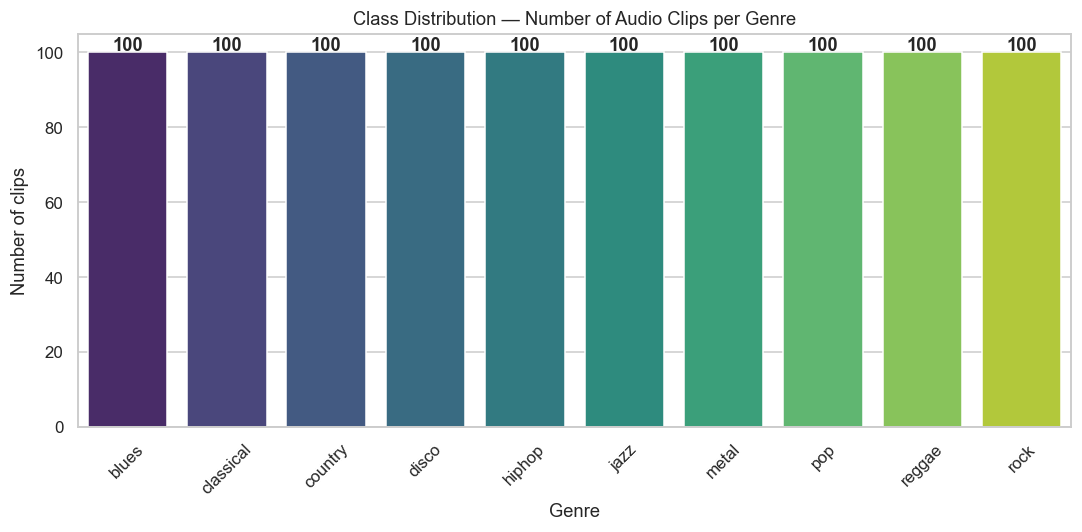

In [14]:
plt.figure(figsize=(10, 5))
counts = files["genre"].value_counts().sort_index()
ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
                 palette="viridis", legend=False)
ax.set_title("Class Distribution — Number of Audio Clips per Genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of clips")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Sample rate — GTZAN standard is 22050 Hz (22050 measurements per second)
SR = 22050

# Empty dictionary to store one audio sample per genre
samples = {}

# Loop through each genre
for g in GENRES:
    # Get all file paths for this genre
    paths = files.loc[files["genre"] == g, "path"].tolist()
    
    # Try each file until one loads successfully
    for p in paths:
        try:
            # Load the audio file as a numpy array (y) at our standard sample rate
            y, sr = librosa.load(p, sr=SR, mono=True)
            
            # Store the audio array, sample rate and filename in the dictionary
            samples[g] = (y, sr, Path(p).name)
            
            # Stop after the first successful load for this genre
            break
        except Exception as e:
            # If the file is corrupted, skip it and try the next one
            print(f"skip {Path(p).name}: {e}")

# Confirm one sample was loaded for each genre
print("Loaded one sample per genre:", list(samples.keys()))

Loaded one sample per genre: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


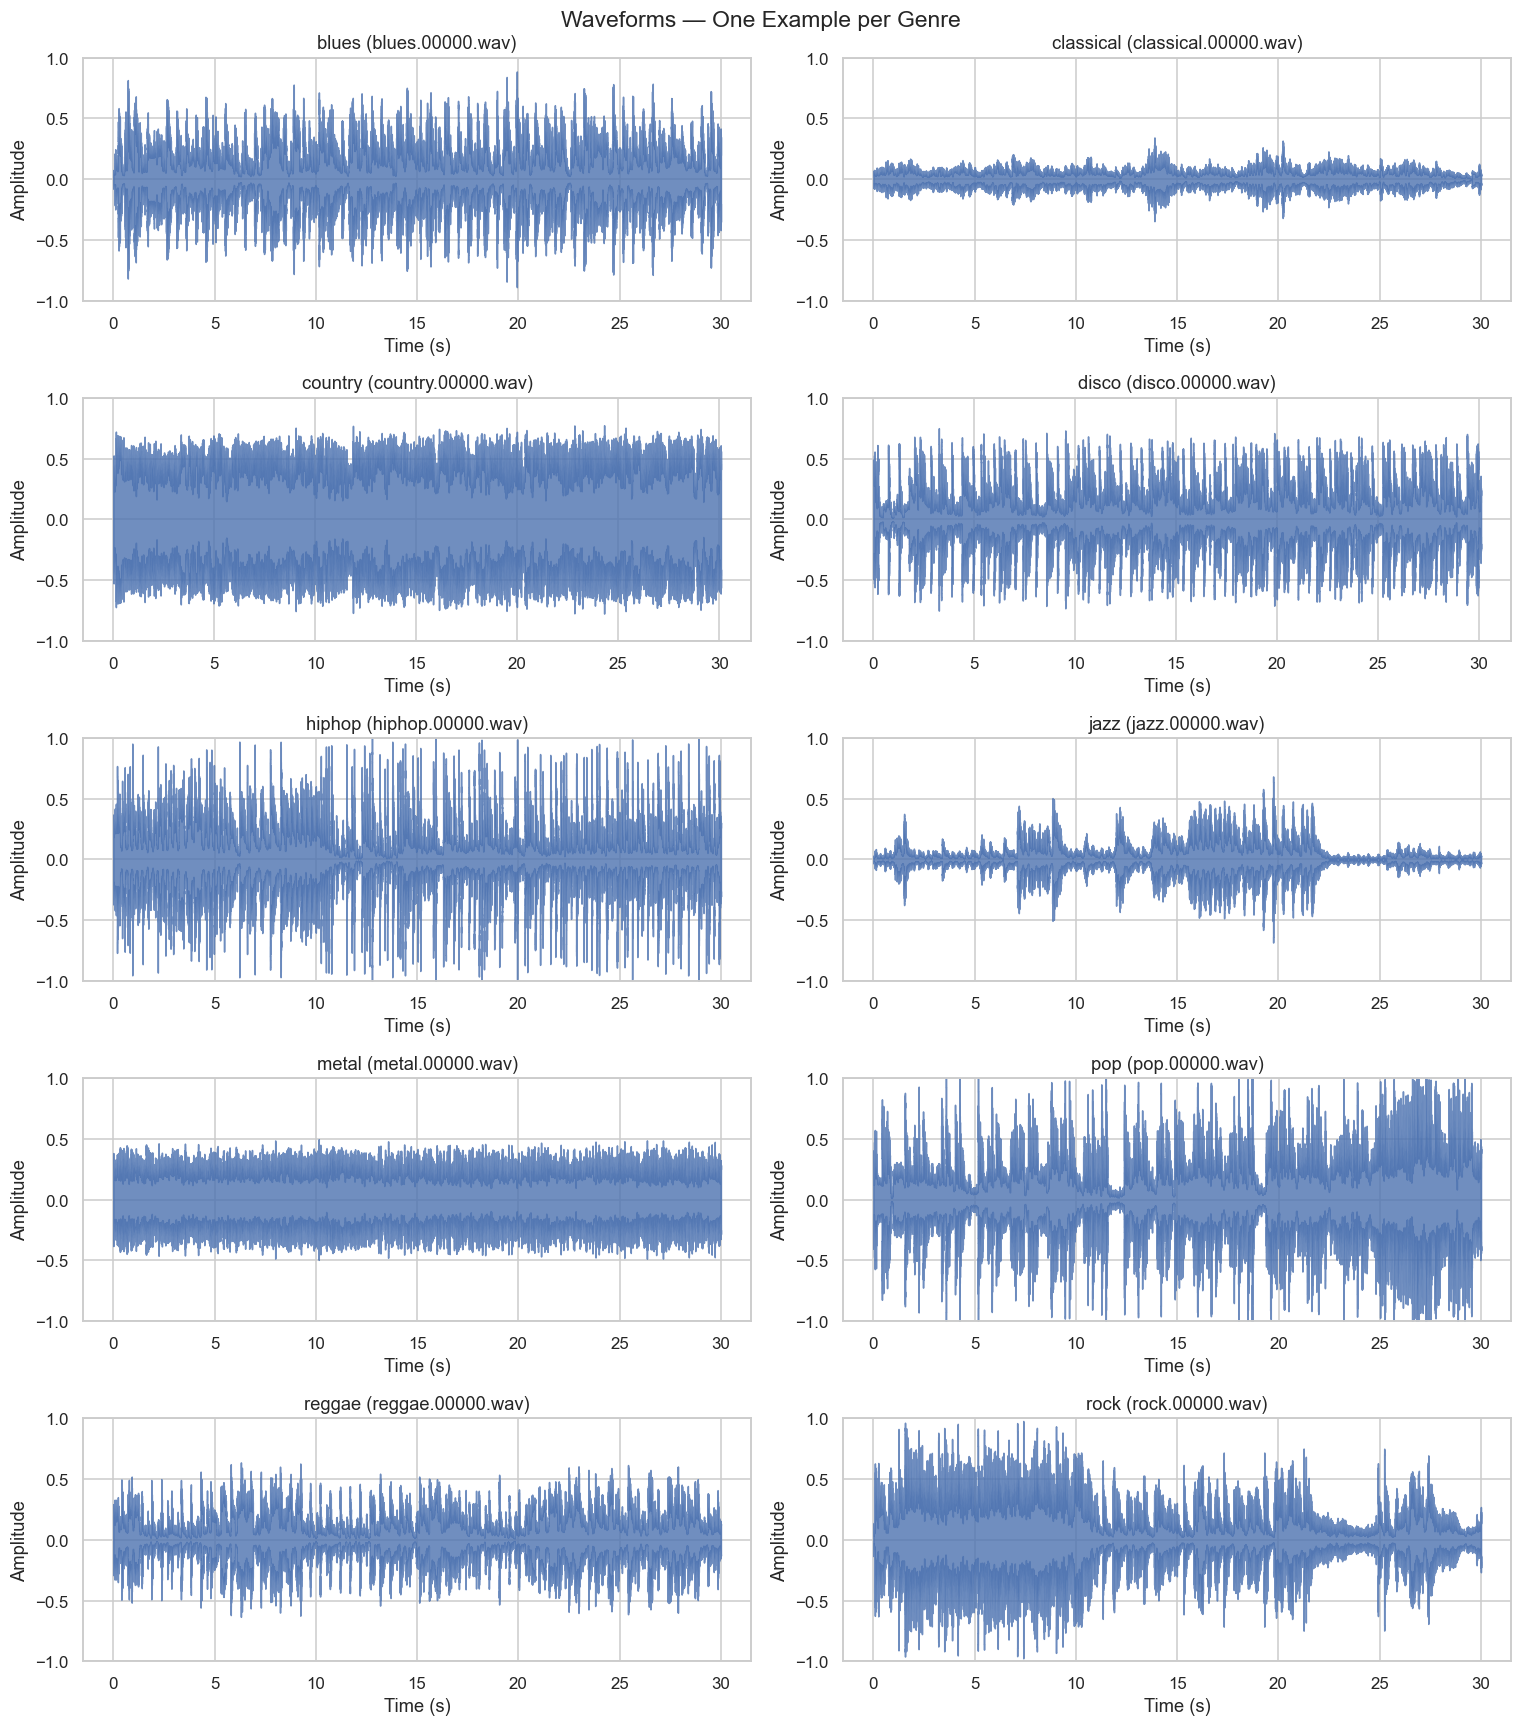

In [16]:
# Create a grid of 5 rows and 2 columns for the 10 genres
fig, axes = plt.subplots(5, 2, figsize=(14, 16))

# Loop through each genre and its corresponding subplot
for ax, g in zip(axes.flat, GENRES):
    # Unpack the audio array, sample rate and filename
    y, sr, name = samples[g]
    
    # Plot the waveform — amplitude over time
    librosa.display.waveshow(y, sr=sr, ax=ax, alpha=0.8)
    
    # Set title and labels
    ax.set_title(f"{g} ({name})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_ylim([-1, 1])

fig.suptitle("Waveforms — One Example per Genre", fontsize=15)
plt.tight_layout()
plt.show()

## Summary Waveforms
The waveforms reveal clear differences in dynamics across genres. 
Classical and jazz show wide dynamic range with quiet and loud passages. 
Country and metal are the loudest genres country reaches ±0.75 amplitude 
and metal stays dense and uniform throughout the entire 30 seconds with no 
quiet moments. These visual differences suggest that amplitude patterns 
alone carry useful genre information.

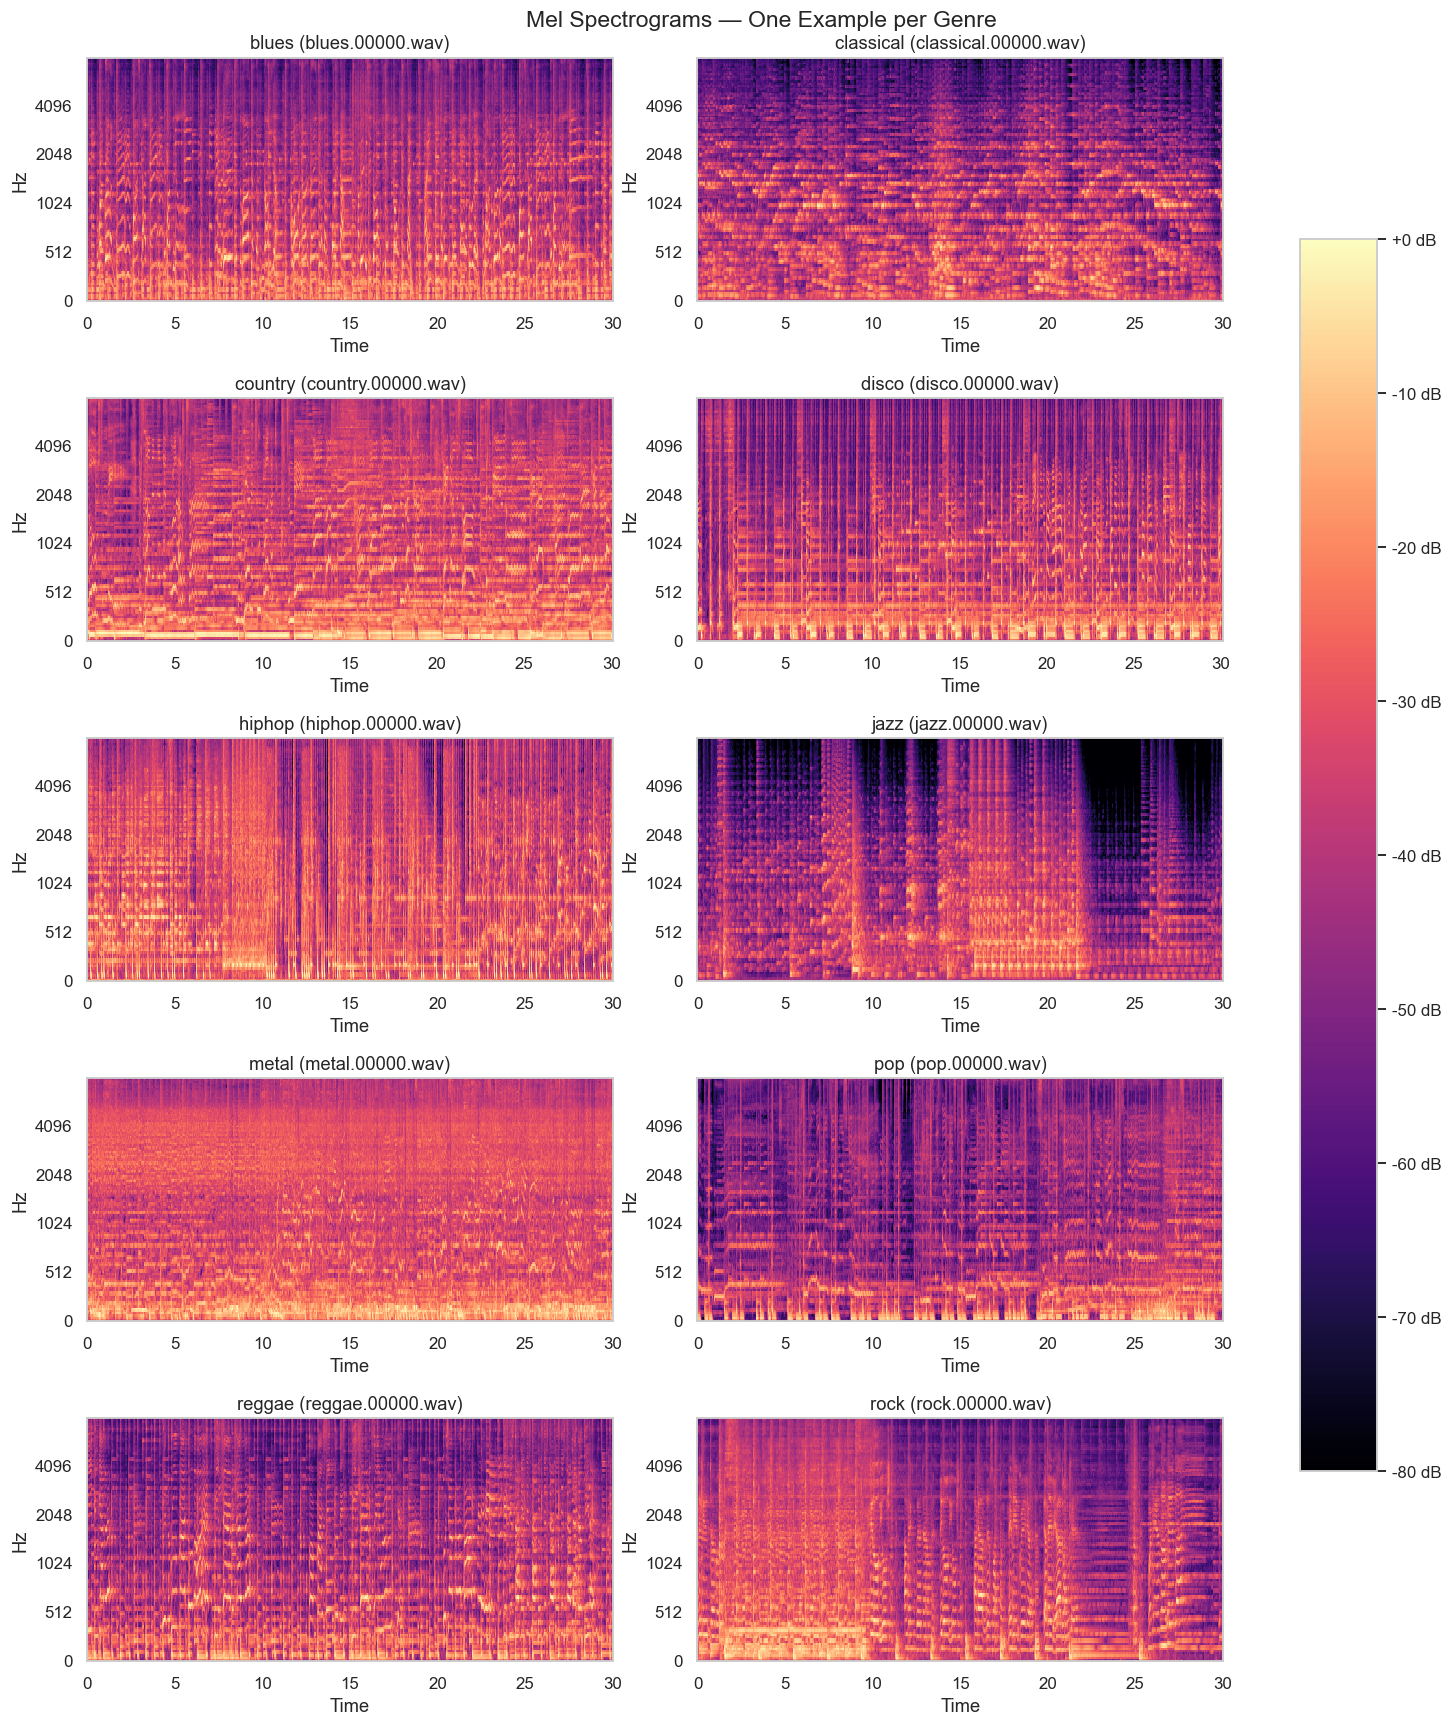

In [17]:
# Create a grid of 5 rows and 2 columns for the 10 genres
fig, axes = plt.subplots(5, 2, figsize=(14, 16))

# Loop through each genre and its corresponding subplot
for ax, g in zip(axes.flat, GENRES):
    # Unpack the audio array, sample rate and filename
    y, sr, name = samples[g]
    
    # Convert audio to mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    
    # Convert power to decibels (more readable scale)
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # Plot the spectrogram — frequency over time
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel",
                                   fmax=8000, ax=ax, cmap="magma", vmin=-80, vmax=0)
    ax.set_title(f"{g} ({name})")


fig.suptitle("Mel Spectrograms — One Example per Genre", fontsize=15)
plt.tight_layout()

# Shift subplots to make room for colobar
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(img, cax=cbar_ax, format="%+2.0f dB")
plt.show()

## Mel Spectrograms
The spectrograms confirm what the waveforms suggested. **`Metal and hiphop`**
show high energy across all frequencies throughout the entire clip. 
**`Classical and jazz`** concentrate energy in low and mid frequencies, with 
jazz showing a notable silent section at the end. Disco and **`pop`** show 
clear repetitive vertical patterns revealing a strong beat. **`Reggae`** shows 
energy concentrated in low frequencies. These differences are strong 
evidence that genres are visually separable, which is exactly what a 
model needs.

### How to read the colors
The colors represent energy (in decibels) at each frequency at each moment in time:
- **Bright yellow/orange** → high energy, the sound is loud at that frequency
- **Purple** → low energy, the sound is weak at that frequency
- **Black** → almost no energy, silence at that frequency

The scale on the right goes from **0 dB** (maximum) to **-60 or -80 dB** 
(near silence). The brighter the color, the louder the sound at that 
frequency and moment.

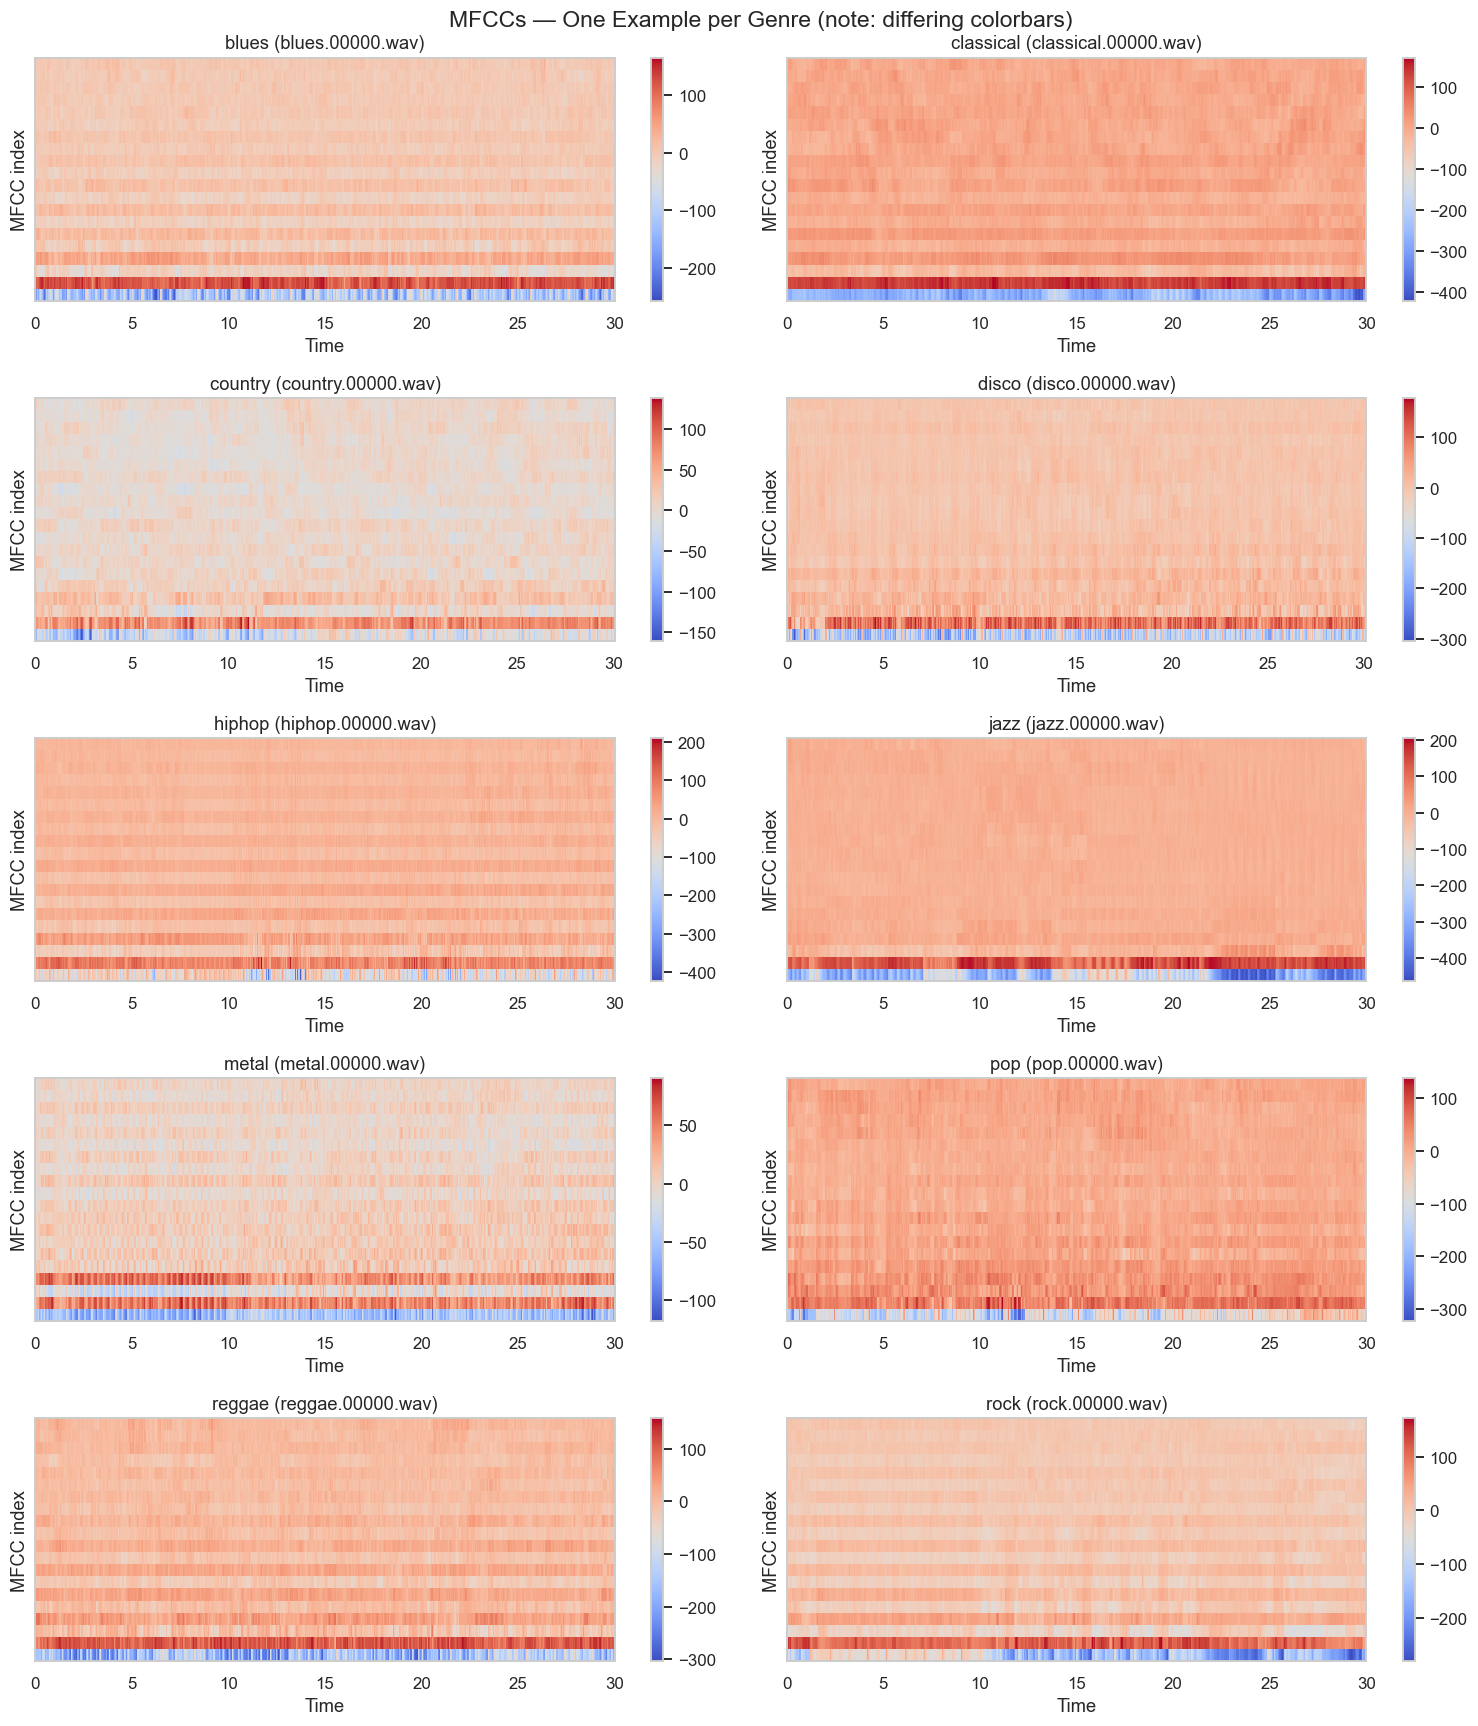

In [18]:
# Create a grid of 5 rows and 2 columns for the 10 genres
fig, axes = plt.subplots(5, 2, figsize=(14, 16))

# Loop through each genre and its corresponding subplot
for ax, g in zip(axes.flat, GENRES):
    # Unpack the audio array, sample rate and filename
    y, sr, name = samples[g]
    
    # Extract 20 MFCC coefficients from the audio
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    
    # Plot the MFCCs — coefficients over time
    img = librosa.display.specshow(mfcc, sr=sr, x_axis="time", 
                                   ax=ax, cmap="coolwarm")
    
    # Add colorbar and title
    fig.colorbar(img, ax=ax)
    ax.set_title(f"{g} ({name})")
    ax.set_ylabel("MFCC index")

fig.suptitle("MFCCs — One Example per Genre (note: differing colorbars)", fontsize=15)
plt.tight_layout()
plt.show()

## MFCCs (mel-frequency cepstral coefficients)
The MFCCs compress the spectrogram into 20 coefficients that capture 
the timbre of each genre. The first coefficient (bottom row) captures 
overall loudness and appears consistently across all genres. Metal shows 
a strong and uniform red band in the middle coefficients, reflecting its 
aggressive and consistent timbre. Country shows the most dispersed and 
light pattern, indicating a more varied timbre. Classical and jazz show 
softer patterns with less intensity in the higher coefficients. These 
differences confirm that MFCCs carry meaningful genre information and 
will be strong features for a classification model.

In [19]:
# Empty lists to store metadata
rows = []
corrupted = []

# Loop through every file in the dataset
for r in files.itertuples(index=False):
    try:
        # Read only the header of the file (fast, no full audio decode)
        info = sf.info(r.path)
        
        # Store the metadata
        rows.append({
            "genre": r.genre,
            "filename": r.filename,
            "duration": info.frames / info.samplerate,
            "sample_rate": info.samplerate,
            "channels": info.channels,
        })
    except Exception as e:
        # If the file fails store it as corrupted
        corrupted.append({
            "genre": r.genre,
            "filename": r.filename,
            "error": str(e)
        })

# Convert to dataframes
meta = pd.DataFrame(rows)
bad = pd.DataFrame(corrupted)

print(f"Readable files: {len(meta)}")
print(f"Corrupted files: {len(bad)}")
print(f"\nSample rate values:\n{meta['sample_rate'].value_counts()}")
print(f"\nDuration stats:\n{meta['duration'].describe()}")

Readable files: 999
Corrupted files: 1

Sample rate values:
sample_rate
22050    999
Name: count, dtype: int64

Duration stats:
count    999.000000
mean      30.024071
std        0.080951
min       29.931973
25%       30.000181
50%       30.013333
75%       30.013333
max       30.648889
Name: duration, dtype: float64


In [20]:
print("Corrupted file:")
print(bad)

Corrupted file:
  genre        filename                                              error
0  jazz  jazz.00054.wav  Error opening '../Data_Music/genres_original/j...


## Duration & Sample Rate & Corrupted Files

**Sample Rate:** All 999 readable files share the same sample rate of 
22,050 Hz. This means all audio files are consistent and comparable 
for feature extraction.

**Duration:** All clips are approximately 30 seconds long (mean = 30.02s, 
min = 29.93s, max = 30.65s). The small variation is negligible and 
won't affect preprocessing.

**Corrupted File:** One corrupted file was found — jazz.00054.wav. 
This is a well known issue in the dataset, present in all versions. 
This file must be removed before training the model.

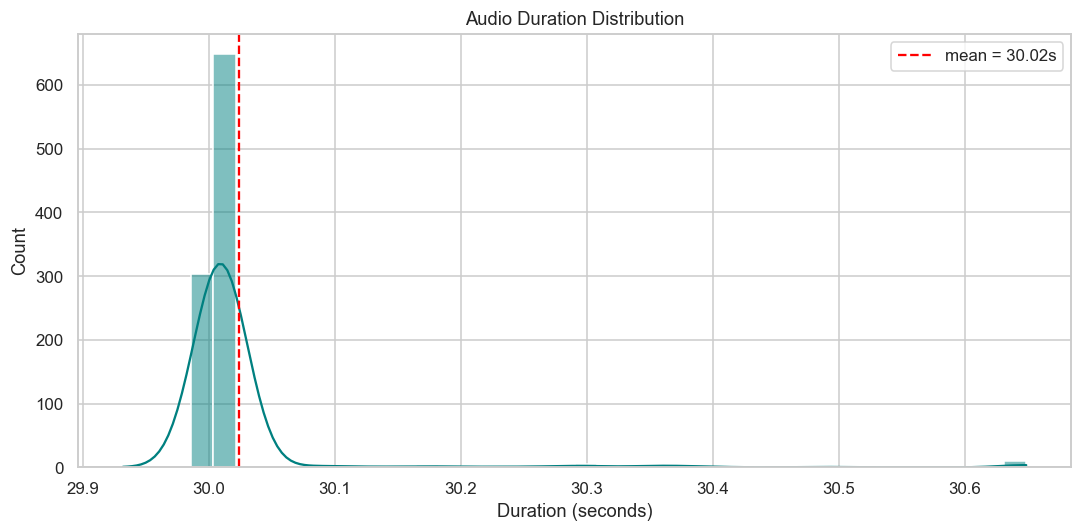

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(meta["duration"], bins=40, kde=True, color="teal")
plt.axvline(meta["duration"].mean(), color="red", ls="--",
            label=f"mean = {meta['duration'].mean():.2f}s")
plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### Duration Distribution
The histogram confirms that almost all clips are exactly **30** seconds long. 
The distribution is tightly concentrated around the mean of **30.02** seconds 
with a very small standard deviation of 0.08s. A few clips reach up to 
**30.65** seconds but this variation is negligible and requires no special 
preprocessing.

## Feature Analysis features_30_sec.csv



In [29]:
# Load the features CSV
features = pd.read_csv(DATA_ROOT / "../Data_Music/features_30_sec.csv")

print("Shape:", features.shape)
print("\nColumns:", list(features.columns))
print("\nFirst rows:")
features.head()

Shape: (1000, 60)

Columns: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']

First rows:


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [30]:
#check for null values in the features dataframe
print("Null values per column:\n", features.isnull().sum()) 
    



Null values per column:
 filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean        

In [31]:
#shape of the features dataframe
print("Shape:", features.shape)

Shape: (1000, 60)


## Univariate Analysis

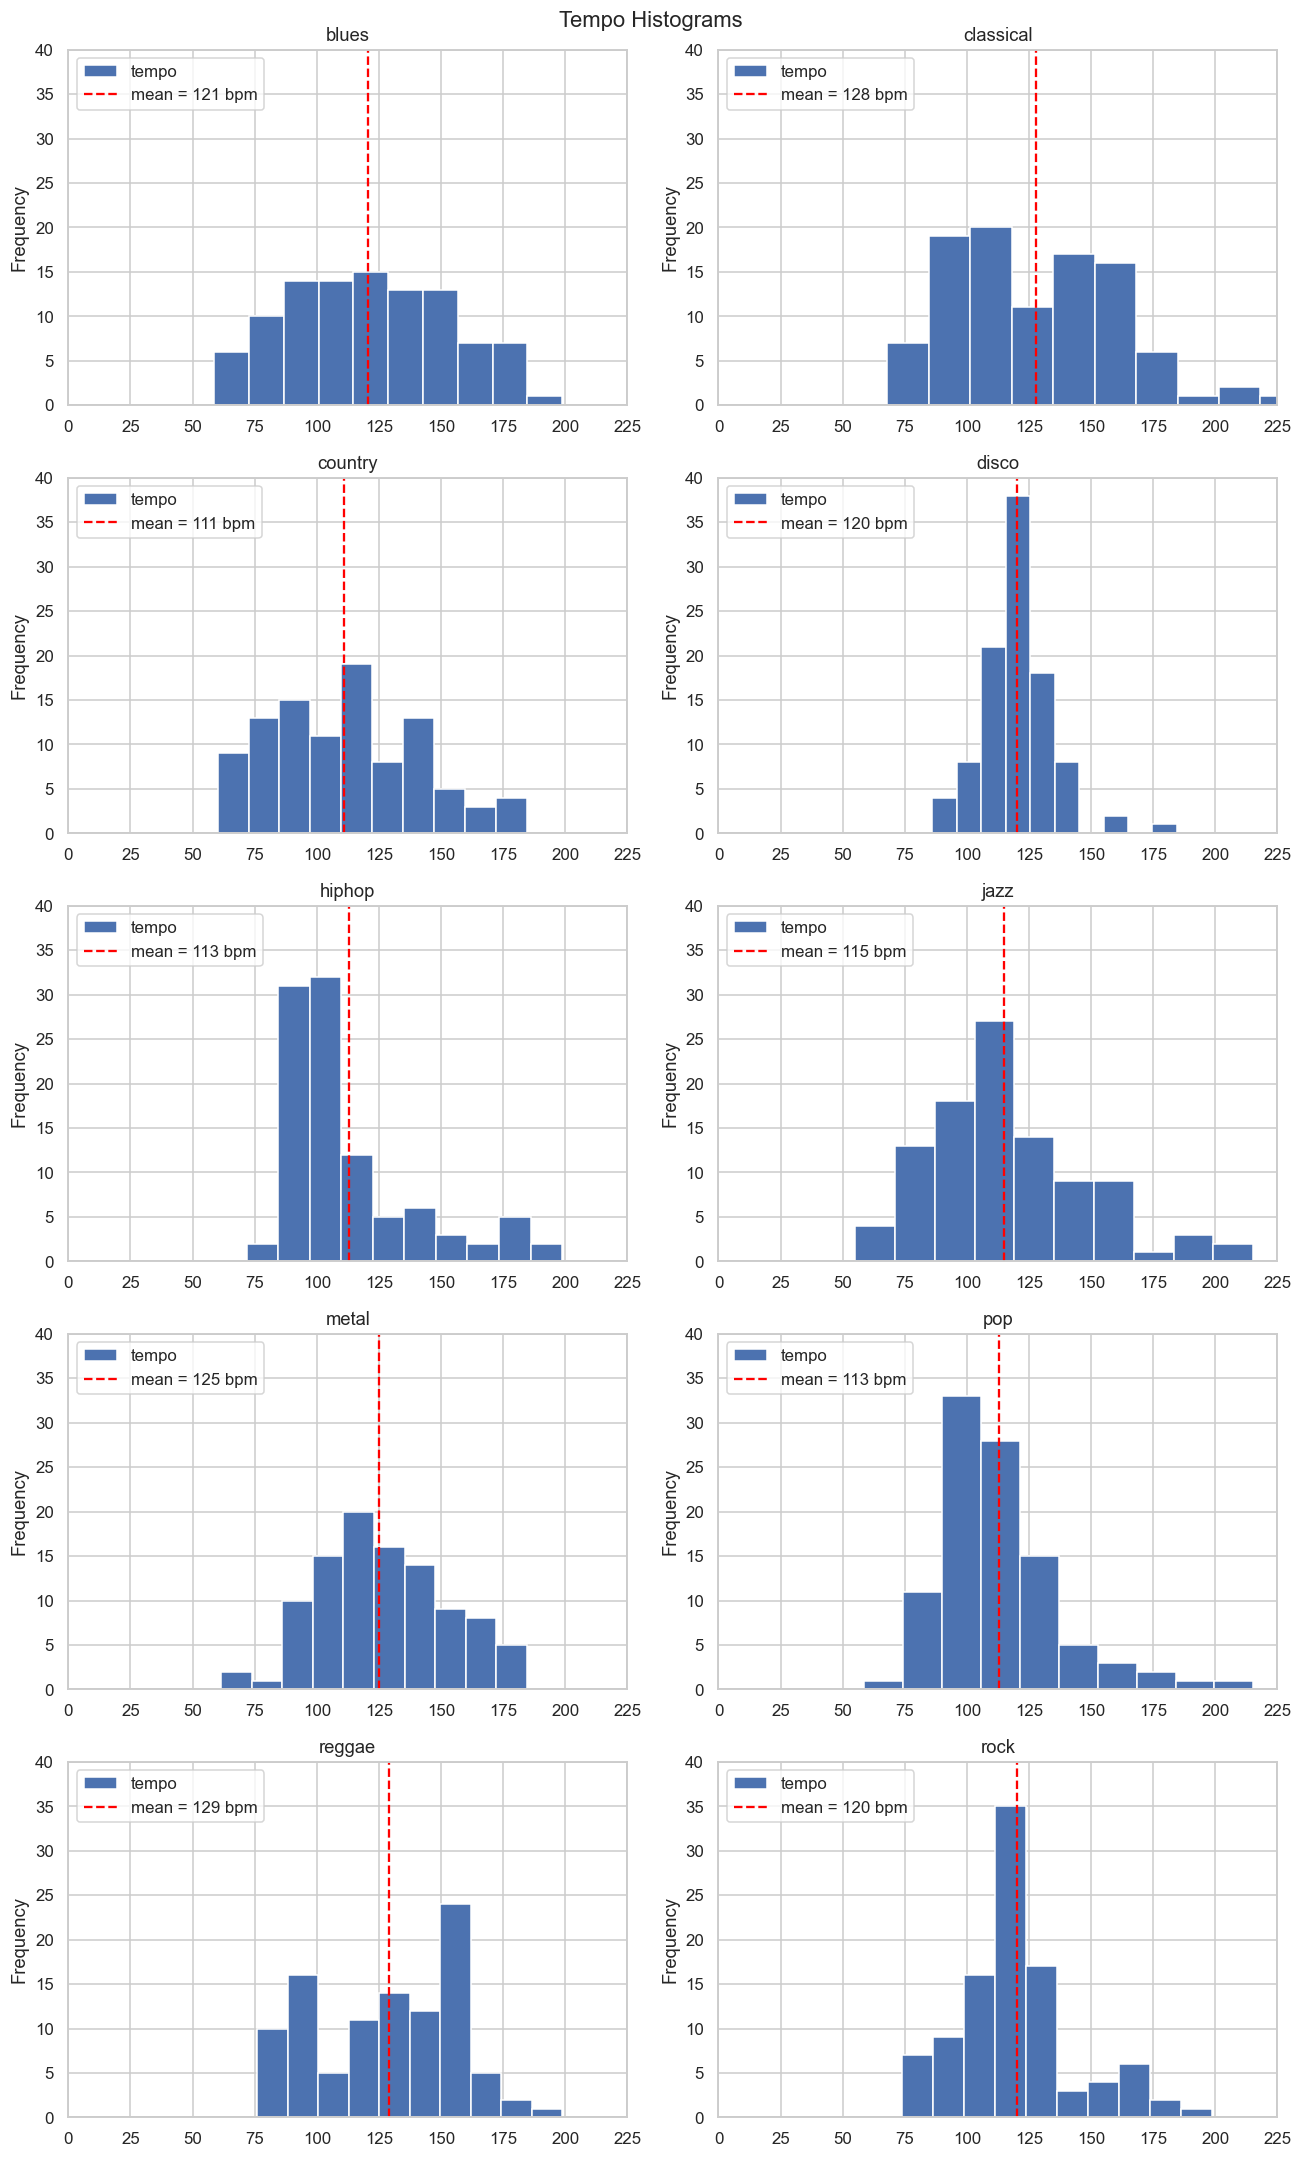

In [32]:
# Revised histogram figure for tempo
# The original figure tried to do too much and wasn't clear
fig, axes = plt.subplots(5, 2, figsize=(12, 20))

for g, ax in zip(GENRES, axes.ravel()):
    tempo = features[features['label'] == g]['tempo']
    tempo.plot.hist(ax=ax, title=g)
    mean = tempo.mean()
    ax.set_xlim([0, 225])
    ax.set_ylim([0, 40])
    ax.axvline(x=mean, color="red", ls="--", label=f"mean = {mean:.0f} bpm")
    ax.legend(loc='upper left')
    fig.suptitle('Tempo Histograms')
    fig.tight_layout()

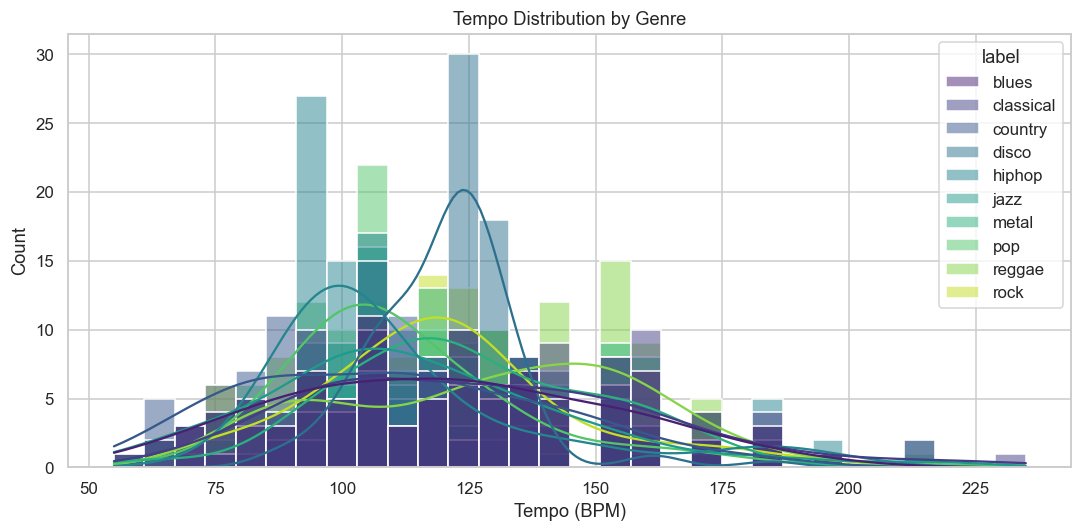

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(data=features, x="tempo", hue="label", 
             bins=30, kde=True, palette="viridis")
plt.title("Tempo Distribution by Genre")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Tempo Distribution
The tempo distribution shows that disco and hiphop are concentrated 
between 100-130 BPM with a consistent fast rhythm. Classical and jazz 
show wider and slower distributions. Most genres overlap between 
100-130 BPM, which means tempo alone is not enough to classify genres 
the model will need multiple features combined to make accurate predictions.

## Bivariate Analysis

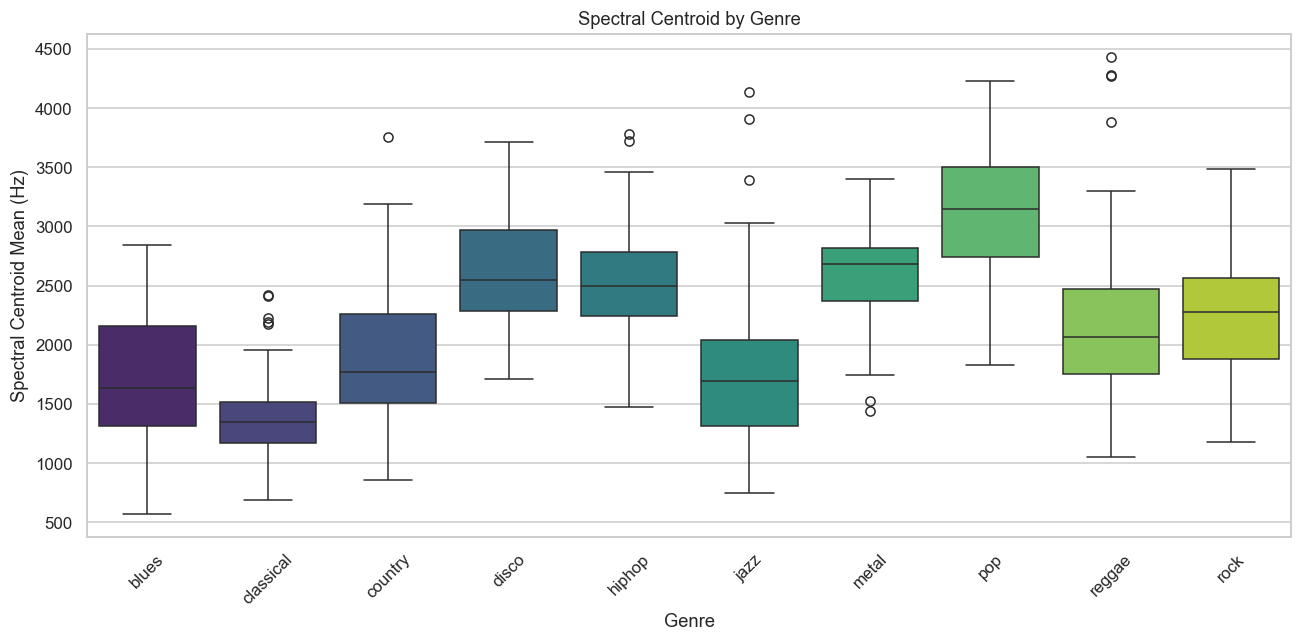

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=features, x="label", y="spectral_centroid_mean",
            hue="label", palette="viridis", legend=False)
plt.title("Spectral Centroid by Genre")
plt.xlabel("Genre")
plt.ylabel("Spectral Centroid Mean (Hz)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Spectral Centroid by Genre
The spectral centroid measures the brightness of the sound. Pop is the 
brightest genre with a mean around 3000-3200 Hz while classical is the 
darkest at 1300 Hz. This single feature already separates some genres 
clearly, particularly classical vs pop. However blues, country and jazz 
overlap significantly, confirming that no single feature is enough and 
the model needs multiple features combined.

## Multivariate Analysis

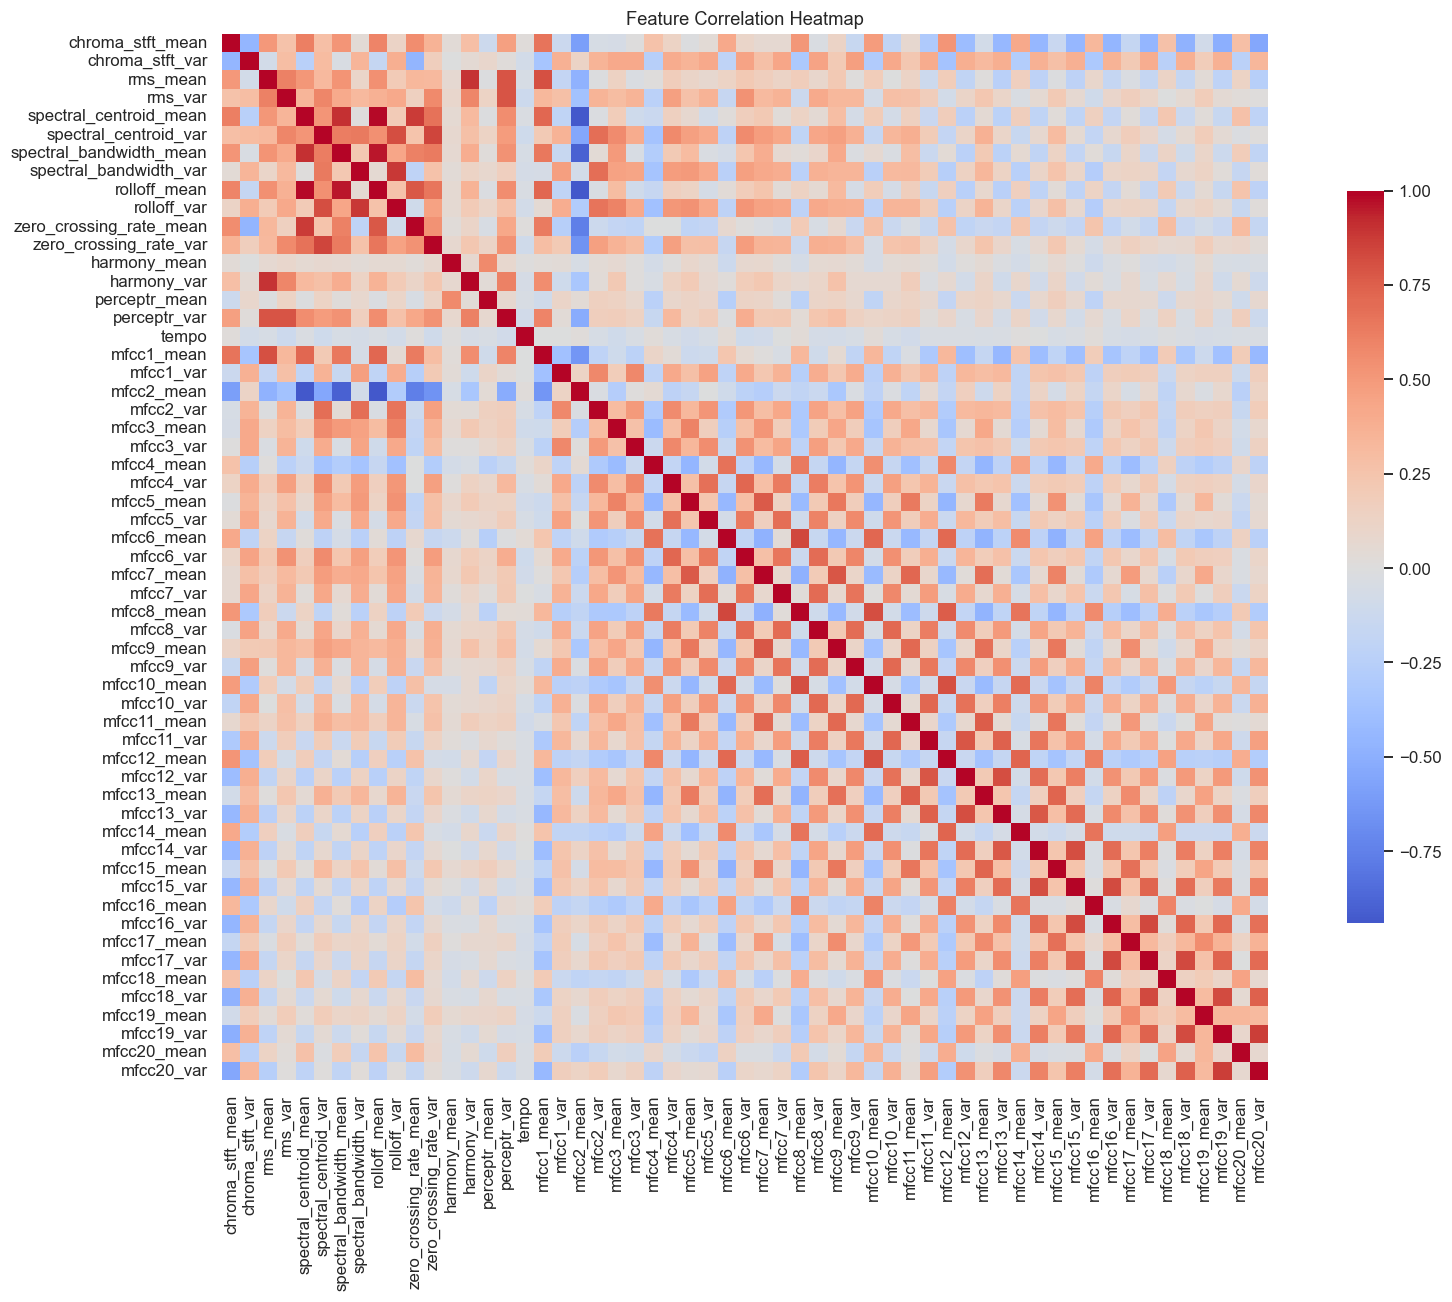

In [35]:
# Select only numeric columns excluding filename and label
numeric_features = features.select_dtypes(include=[np.number]).drop(
    columns=["length"], errors="ignore"
)

# Calculate correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(numeric_features.corr(), 
            cmap="coolwarm", 
            center=0, 
            square=True,
            cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Feature Correlation Heatmap
The correlation heatmap reveals meaningful relationships among audio 
descriptors. Spectral features such as **`spectral centroid`**, **`bandwidth`**, 
**`rolloff`**, and **`zero-crossing rate`** exhibit moderate to strong positive 
correlations, indicating that they capture related aspects of frequency 
content and timbral brightness. MFCC features form a structured 
correlation pattern, where adjacent coefficients tend to be positively 
correlated, reflecting the smooth nature of the spectral envelope 
representation. Chroma features show weaker correlations with other 
feature groups, suggesting they provide complementary harmonic 
information. Tempo appears largely independent from the remaining 
variables, contributing unique rhythmic characteristics. Overall, while 
some feature redundancy exists, the dataset does not exhibit widespread 
extreme multicollinearity, supporting the use of the full feature set 
during initial modeling and feature importance analysis.

## Hypothesis

Based on the exploratory data analysis, we hypothesize that music genre 
classification can be performed effectively using the extracted audio 
features from the GTZAN dataset.

### Rationale
- The dataset is balanced across all genres, with 100 audio clips per 
  class, reducing the risk of model bias toward any particular genre.
- Waveform, spectrogram, and MFCC visualizations reveal distinct acoustic 
  patterns across genres.
- Several audio features, such as spectral centroid and spectral rolloff, 
  show meaningful differences between genres.
- Correlation analysis suggests that many features provide complementary 
  information rather than being entirely redundant.

### Expected Challenges
- Genres such as blues, country, and rock exhibit similar audio 
  characteristics and may be difficult to separate.
- Tempo distributions overlap considerably across genres, limiting its 
  discriminative power as a standalone feature.
- The corrupted file `jazz.00054.wav` should be removed during 
  preprocessing to ensure data quality.

### Expected Outcome
We expect machine learning models trained on the extracted audio features 
to achieve performance substantially above the 10% random baseline. 
Genres with distinctive acoustic characteristics, such as classical and 
metal, are expected to achieve higher classification accuracy, while 
blues, country, and rock are likely to generate the highest number of 
classification errors.